In [32]:
import os
import sys
import json
import logging
import argparse
import torch
from scipy.sparse import issparse
import numpy as np
import anndata as ad
import pandas as pd

print("MPS available:", torch.backends.mps.is_available())
print("CUDA version:", torch.version.cuda)

# Show MPS device info safely
if torch.backends.mps.is_available():
    print("MPS backend is active on macOS (Metal).")
    print("Device: Apple GPU via Metal Performance Shaders (MPS).")
else:
    print("MPS not available — running on CPU instead.")

print("CPU cores:", os.cpu_count())


MPS available: False
CUDA version: 11.7
MPS not available — running on CPU instead.
CPU cores: 48


In [33]:
import scanpy as sc
# Load your dataset
adata_sc = sc.read_h5ad("./scrna-sciplex3/hvg.h5ad")

# Basic overview
print(adata_sc)
print("Shape:", adata_sc.shape)

# View column names (metadata about each cell)
print("Observation columns:", adata_sc.obs.columns.tolist()[:10])
print("Feature columns:", adata_sc.var_names[:10].tolist())

# How many drugs (conditions)?
print("Unique conditions:", adata_sc.obs['drug'].unique())
print("Number of cells per condition:")
print(adata_sc.obs['drug'].value_counts())



AnnData object with n_obs × n_vars = 762039 × 1000
    obs: 'size_factor', 'cell_type', 'replicate', 'dose', 'drug_code', 'pathway_level_1', 'pathway_level_2', 'product_name', 'target', 'pathway', 'drug', 'drug-dose', 'drug_code-dose', 'n_genes'
    var: 'gene_short_name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'rank_genes_groups'
    obsm: 'X_pca'
    varm: 'PCs', 'marker_genes-drug-rank', 'marker_genes-drug-score'
Shape: (762039, 1000)
Observation columns: ['size_factor', 'cell_type', 'replicate', 'dose', 'drug_code', 'pathway_level_1', 'pathway_level_2', 'product_name', 'target', 'pathway']
Feature columns: ['ENSG00000243620.1', 'ENSG00000271503.5', 'ENSG00000259124.1', 'ENSG00000121101.15', 'ENSG00000160963.13', 'ENSG00000135346.8', 'ENSG00000143839.14', 'ENSG00000100867.14', 'ENSG00000140986.7', 'ENSG00000230666.5']
Unique conditions: ['tak_901', 'ag_490', 'abexinostat', 'alisertib', 'busulfan', ..., 'ac480', 'cediranib', 't

In [34]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [57]:
def AOT(
    X_tr_pre, Y_tr_post, X_te_pre, Y_te_post,
    top_feature_subset: Optional[List[int]] = None,
    n_epochs=3000, batch_size=2048, lr=1e-3, device="auto", seed=12345, verbose=True
):
    import torch, numpy as np, random, ot
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler


    # ---------------- Device check ---------------- #
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    
    # Helper: only pin memory for CPU→CUDA pipeline
    def should_pin(device, tensor):
        return (device.startswith("mps") and tensor.device.type == "cpu")

    # ---------------- Helper Functions ---------------- #
    def cost_matrix(X, Y):
        X2 = (X**2).sum(1, keepdims=True)
        Y2 = (Y**2).sum(1, keepdims=True).T
        return X2 + Y2 - 2 * X @ Y.T

    def exact_ot_plan(X, Y):
        a, b = torch.ones(len(X)), torch.ones(len(Y))
        C = cost_matrix(X, Y)
        Pi = ot.emd(a, b, C, numItermax=1e7)
        return Pi, C

    class Mapper(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.first = nn.Linear(d, d, bias=False)
            nn.init.eye_(self.first.weight)
        def forward(self, x):
            return self.first(x)
        def loss(self, Xmap, Y, P):
            return torch.norm(Y - P.T @ Xmap)**2

    # ---------------- Data Setup ---------------- #
    scaler = StandardScaler()

    XY = np.vstack([X_tr_pre, Y_tr_post])
    XYs = torch.tensor(scaler.fit_transform(XY), dtype=torch.float32, device=device)

    n = len(X_tr_pre)
    Xtr_s = XYs[:n]
    Ytr_s = XYs[n:]

    Xte_s = torch.tensor(scaler.transform(X_te_pre), dtype=torch.float32, device=device)
    Yte = torch.tensor(Y_te_post, dtype=torch.float32, device=device)

    # Build dataloader (pin only if CPU→CUDA)
    pin = should_pin(device, Xtr_s)
    train_loader = DataLoader(
        TensorDataset(Xtr_s, Ytr_s),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin
    )

    # ---------------- Seed ---------------- #
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)

    mapper = Mapper(X_tr_pre.shape[1]).to(device)
    opt = torch.optim.Adam(mapper.parameters(), lr=lr, weight_decay=1e-4)

    # ---------------- Training Loop ---------------- #
    for epoch in range(n_epochs+1):
        mapper.train()
        for bx, by in train_loader:

            Xmap = mapper(bx)
            with torch.no_grad():
                P,_ = exact_ot_plan(Xmap, by)
                if isinstance(P, np.ndarray):
                    P = torch.from_numpy(P).to(device=device, dtype=torch.float32)
                else:
                    P = P.clone().detach().to(device=device, dtype=torch.float32)
                    
            opt.zero_grad(set_to_none=True)
            loss = mapper.loss(Xmap, by, P)
            loss.backward()
            opt.step()

        # Logging
        if verbose and epoch % 10 == 0:
            mapper.eval()
            with torch.no_grad():
                train_map = mapper(Xtr_s)
                train_map_unscaled = scaler.inverse_transform(train_map.cpu().numpy())
                Y_train_unscaled = scaler.inverse_transform(Ytr_s.cpu().numpy())
                train_mmd = mmd_distance(train_map_unscaled[:, ], Y_train_unscaled[:, ], gamma=median_gamma)

                te_s = mapper(Xte_s)
                te = scaler.inverse_transform(te_s.cpu())
                test_mmd = mmd_distance(te[:, ], Yte.cpu().numpy()[:, ], gamma=median_gamma)
                test_wasserstein = wasserstein_pointcloud(te[:, ], Yte.cpu().numpy()[:, ])

            print(f"Epoch {epoch} | Train Loss {loss.item():.4f} | Train MMD {train_mmd:.4f} | Test MMD {test_mmd:.4f} | Test Wasserstein {test_wasserstein:.4f}")


    # ---------------- Final Eval ---------------- #
    mapper.eval()
    with torch.no_grad():
        te_s = mapper(Xte_s)
        te = scaler.inverse_transform(te_s.cpu().numpy())
        test_mmd = mmd_distance(te[:, ], Yte.cpu().numpy()[:, ], gamma=median_gamma)
        test_wasserstein = wasserstein_pointcloud(te[:, ], Yte.cpu().numpy()[:, ])

    recovered_perm = torch.argmax(P, axis=1).cpu().numpy()
    return {
        "y_pred": te,
        "test_mmd": test_mmd,
        "test_wasserstein": test_wasserstein,
        "model": mapper,
        "scaler": scaler,
        "device": device,
        "recovered_perm": recovered_perm
    }


In [49]:
drug = "trametinib"
X_pre = adata_sc[adata_sc.obs["drug"] == "control"].copy().to_df()
X_post  = adata_sc[adata_sc.obs["drug"] == drug].copy().to_df()

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

top_genes_ids, top_genes_short, top_genes_idx = topk_markers(adata_sc, drug, k=100)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


X_pre cells: (17565, 1000)
X_post cells: (3277, 1000)
(2621, 1000)
(656, 1000)
(2621, 1000)
(656, 1000)
Median heuristic gamma: 0.0022858211277792303


In [51]:
# Multiple runs for robustness
all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=200, batch_size=4096, lr=1e-4, device="cuda", verbose=True, top_feature_subset=top_genes_idx, seed=seed)
    metrics = summarize_metrics(out["y_pred"][:, top_genes_idx], Y_te_post[:, top_genes_idx], median_gamma)
    print("Metrics:", metrics)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print("=== Metrics Summary over Runs for top 100 genes ===")
print(df.describe().T[['mean', 'std']].round(4))

**************** Run: 0 ****************
Epoch 0 | Train Loss 3746983.5000 | Train MMD 0.0092 | Test MMD 0.0117 | Test Wasserstein 7.5287
Epoch 10 | Train Loss 3616252.5000 | Train MMD 0.0077 | Test MMD 0.0109 | Test Wasserstein 7.3324
Epoch 20 | Train Loss 3508505.2500 | Train MMD 0.0071 | Test MMD 0.0100 | Test Wasserstein 7.2164
Epoch 30 | Train Loss 3412116.5000 | Train MMD 0.0068 | Test MMD 0.0091 | Test Wasserstein 7.1416
Epoch 40 | Train Loss 3323678.0000 | Train MMD 0.0065 | Test MMD 0.0083 | Test Wasserstein 7.0993
Epoch 50 | Train Loss 3241594.0000 | Train MMD 0.0062 | Test MMD 0.0077 | Test Wasserstein 7.0778
Epoch 60 | Train Loss 3164914.7500 | Train MMD 0.0058 | Test MMD 0.0072 | Test Wasserstein 7.0666
Epoch 70 | Train Loss 3092988.2500 | Train MMD 0.0056 | Test MMD 0.0067 | Test Wasserstein 7.0626
Epoch 80 | Train Loss 3025315.7500 | Train MMD 0.0054 | Test MMD 0.0063 | Test Wasserstein 7.0638
Epoch 90 | Train Loss 2961495.7500 | Train MMD 0.0052 | Test MMD 0.0060 | Test

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


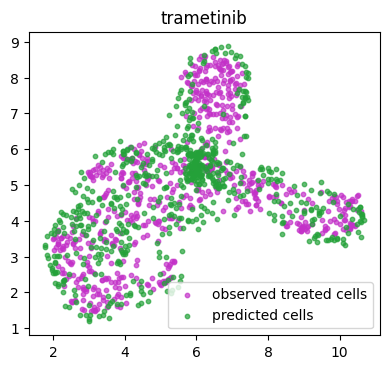

In [ ]:
from umap import UMAP
import matplotlib.pyplot as plt

source = out["y_pred"][:,]
target = Y_te_post[:, top_genes_idx]


# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)


fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C331C8")
ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#24A139")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

In [52]:
drug = "givinostat"
X_pre = adata_sc[adata_sc.obs["drug"] == "control"].copy().to_df()
X_post  = adata_sc[adata_sc.obs["drug"] == drug].copy().to_df()

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

top_genes_ids, top_genes_short, top_genes_idx = topk_markers(adata_sc, drug, k=100)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


X_pre cells: (17565, 1000)
X_post cells: (3541, 1000)
(2832, 1000)
(709, 1000)
(2832, 1000)
(709, 1000)
Median heuristic gamma: 0.002211581349119358


In [53]:
# Multiple runs for robustness
all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=200, batch_size=4096, lr=1e-4, device="cuda", verbose=True, top_feature_subset=top_genes_idx, seed=seed)
    metrics = summarize_metrics(out["y_pred"][:, top_genes_idx], Y_te_post[:, top_genes_idx], median_gamma)
    print("Metrics:", metrics)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print("=== Metrics Summary over Runs for top 100 genes ===")
print(df.describe().T[['mean', 'std']].round(4))

**************** Run: 0 ****************
Epoch 0 | Train Loss 4142389.7500 | Train MMD 0.0110 | Test MMD 0.0132 | Test Wasserstein 8.0244
Epoch 10 | Train Loss 4016080.0000 | Train MMD 0.0093 | Test MMD 0.0128 | Test Wasserstein 7.9222
Epoch 20 | Train Loss 3908877.0000 | Train MMD 0.0087 | Test MMD 0.0120 | Test Wasserstein 7.8655
Epoch 30 | Train Loss 3810793.0000 | Train MMD 0.0084 | Test MMD 0.0110 | Test Wasserstein 7.8190
Epoch 40 | Train Loss 3720023.2500 | Train MMD 0.0081 | Test MMD 0.0101 | Test Wasserstein 7.7894
Epoch 50 | Train Loss 3635463.2500 | Train MMD 0.0078 | Test MMD 0.0093 | Test Wasserstein 7.7704
Epoch 60 | Train Loss 3556318.7500 | Train MMD 0.0075 | Test MMD 0.0086 | Test Wasserstein 7.7560
Epoch 70 | Train Loss 3482020.7500 | Train MMD 0.0072 | Test MMD 0.0079 | Test Wasserstein 7.7445
Epoch 80 | Train Loss 3412084.0000 | Train MMD 0.0070 | Test MMD 0.0073 | Test Wasserstein 7.7366
Epoch 90 | Train Loss 3346111.2500 | Train MMD 0.0068 | Test MMD 0.0067 | Test

In [54]:
drug = "abexinostat"
X_pre = adata_sc[adata_sc.obs["drug"] == "control"].copy().to_df()
X_post  = adata_sc[adata_sc.obs["drug"] == drug].copy().to_df()

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

top_genes_ids, top_genes_short, top_genes_idx = topk_markers(adata_sc, drug, k=100)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


X_pre cells: (17565, 1000)
X_post cells: (4505, 1000)
(3604, 1000)
(901, 1000)
(3604, 1000)
(901, 1000)
Median heuristic gamma: 0.0021515925828798567


In [55]:
# Multiple runs for robustness
all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=200, batch_size=4096, lr=1e-4, device="cuda", verbose=True, top_feature_subset=top_genes_idx, seed=seed)
    metrics = summarize_metrics(out["y_pred"][:, top_genes_idx], Y_te_post[:, top_genes_idx], median_gamma)
    print("Metrics:", metrics)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print("=== Metrics Summary over Runs for top 100 genes ===")
print(df.describe().T[['mean', 'std']].round(4))

**************** Run: 0 ****************
Epoch 0 | Train Loss 5246983.0000 | Train MMD 0.0147 | Test MMD 0.0203 | Test Wasserstein 7.9843
Epoch 10 | Train Loss 5085231.0000 | Train MMD 0.0132 | Test MMD 0.0185 | Test Wasserstein 7.8207
Epoch 20 | Train Loss 4955467.5000 | Train MMD 0.0122 | Test MMD 0.0167 | Test Wasserstein 7.7213
Epoch 30 | Train Loss 4839393.0000 | Train MMD 0.0113 | Test MMD 0.0149 | Test Wasserstein 7.6603
Epoch 40 | Train Loss 4732824.5000 | Train MMD 0.0104 | Test MMD 0.0133 | Test Wasserstein 7.6215
Epoch 50 | Train Loss 4634250.5000 | Train MMD 0.0097 | Test MMD 0.0120 | Test Wasserstein 7.5952
Epoch 60 | Train Loss 4542612.5000 | Train MMD 0.0092 | Test MMD 0.0108 | Test Wasserstein 7.5771
Epoch 70 | Train Loss 4457099.5000 | Train MMD 0.0088 | Test MMD 0.0098 | Test Wasserstein 7.5632
Epoch 80 | Train Loss 4377058.5000 | Train MMD 0.0086 | Test MMD 0.0090 | Test Wasserstein 7.5536
Epoch 90 | Train Loss 4301951.0000 | Train MMD 0.0084 | Test MMD 0.0082 | Test

KeyboardInterrupt: 

In [59]:
# Multiple runs for robustness
all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre[:, top_genes_idx], Y_tr_post[:, top_genes_idx], X_te_pre[:, top_genes_idx], Y_te_post[:, top_genes_idx], n_epochs=200, batch_size=4096, lr=1e-3, device="cuda", verbose=True,  seed=seed)
    metrics = summarize_metrics(out["y_pred"][:, ], Y_te_post[:, top_genes_idx], median_gamma)
    print("Metrics:", metrics)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print("=== Metrics Summary over Runs for top 100 genes ===")
print(df.describe().T[['mean', 'std']].round(4))

**************** Run: 0 ****************
Epoch 0 | Train Loss 426154.1250 | Train MMD 0.0189 | Test MMD 0.0196 | Test Wasserstein 7.9598
Epoch 10 | Train Loss 391959.4375 | Train MMD 0.0118 | Test MMD 0.0125 | Test Wasserstein 7.6411
Epoch 20 | Train Loss 374228.6562 | Train MMD 0.0073 | Test MMD 0.0079 | Test Wasserstein 7.4776
Epoch 30 | Train Loss 362087.1875 | Train MMD 0.0046 | Test MMD 0.0051 | Test Wasserstein 7.3812
Epoch 40 | Train Loss 353254.2812 | Train MMD 0.0031 | Test MMD 0.0036 | Test Wasserstein 7.3146
Epoch 50 | Train Loss 346384.0625 | Train MMD 0.0024 | Test MMD 0.0028 | Test Wasserstein 7.2617
Epoch 60 | Train Loss 340754.5938 | Train MMD 0.0020 | Test MMD 0.0024 | Test Wasserstein 7.2185
Epoch 70 | Train Loss 335922.9688 | Train MMD 0.0019 | Test MMD 0.0022 | Test Wasserstein 7.1821
Epoch 80 | Train Loss 331653.5312 | Train MMD 0.0018 | Test MMD 0.0021 | Test Wasserstein 7.1495
Epoch 90 | Train Loss 327840.7500 | Train MMD 0.0017 | Test MMD 0.0020 | Test Wasserste

KeyboardInterrupt: 